In [1]:
import torch
import numpy as np
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from Models import *
from DDBSCAN import Raster_DBSCAN
import matplotlib.colors as mcolors
import cv2
from collections import defaultdict
import pandas as pd
from scipy import stats
import seaborn as sns
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment
from filterpy.common import Q_discrete_white_noise
from Utils import *
import os
from SocialLSTM.ModelSocial import LaneSocialLSTM
# times new roman font
plt.rcParams["font.family"] = "Times New Roman"
seed = 414
# np.random.seed(seed)
colors = np.random.rand(600, 3)
colors = np.concatenate([np.array([[0,0,0]]),colors],axis = 0)
colormap = mcolors.ListedColormap(colors)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Encoder Decoder LSTM Evaluation Results

In [ ]:
lane_unit = 200
time_span = 100
hidden_size = 256
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
best_model = BidirectionalLSTMLaneReconstructor(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\EncoderDecoder_EvenlySampled_FreeflowAug_0914_5res_lanechange_signal\models\train_2"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_16.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
# db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[9,15],eps = 1,min_samples=1)

BidirectionalLSTMLaneReconstructor(
  (encoder): LSTM(200, 256, num_layers=2, batch_first=True, bidirectional=True)
  (decoder): LSTM(512, 512, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=512, out_features=200, bias=True)
  (sigmoid): Sigmoid()
)

In [ ]:
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation


        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

100%|██████████| 325/325 [00:11<00:00, 29.37it/s]


In [35]:
df # encode-decoder 256 confidence threshold 0.2-0.9

,ConfThred,TP,FP,FN,IDSwitch,Discontinuity,RecoveredTrajs,precision,recall,F1
0,0.20,1361,146,117,33,11,507,0.903119,0.920839,0.911893
1,0.25,1390,105,88,29,11,515,0.929766,0.940460,0.935082
2,0.30,1422,104,56,24,13,521,0.931848,0.962111,0.946738
3,0.35,1435,97,43,19,15,527,0.936684,0.970907,0.953488
4,0.40,1443,104,35,11,29,530,0.932773,0.976319,0.954050
5,0.45,1448,171,30,6,76,535,0.894379,0.979702,0.935098
6,0.50,1456,267,22,2,151,538,0.845038,0.985115,0.909716
7,0.55,1449,319,29,1,220,536,0.819570,0.980379,0.892791
8,0.60,1419,397,59,1,287,529,0.781388,0.960081,0.861566
9,0.65,1373,443,105,1,325,523,0.756057,0.928958,0.833637


## RNN


In [ ]:

lane_unit = 200
time_span = 100
hidden_size = 256
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
best_model = BidirectionalRNNLaneReconstructor(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\RNN_256_EncoderDecoder_EvenlySampled_FreeflowAug_0402_5res_lanechange_signal\models\train_0"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_16.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation


        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

In [47]:

lane_unit = 200
time_span = 100
hidden_size = 128
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
best_model = BidirectionalRNNLaneReconstructor(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\RNN_128_EncoderDecoder_EvenlySampled_FreeflowAug_0401_5res_lanechange_signal\models\train_0"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_16.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation


        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

 13%|█▎        | 43/325 [00:00<00:06, 46.87it/s]c:\Users\zhChe\anaconda3\envs\tracking3\lib\site-packages\scipy\interpolate\_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
100%|██████████| 325/325 [00:07<00:00, 45.16it/s]


## LSTM attention

In [49]:

lane_unit = 200
time_span = 100
hidden_size = 256
num_layers = 2
input_size = lane_unit
learning_rate = 0.001
num_epochs = 50
best_model = BidirectionalRNNLaneReconstructorWithAttention(input_size, hidden_size, num_layers).to(device)
mocel_save_path = r"D:\TimeSpaceDiagramDataset\LSTM_att_256_EncoderDecoder_EvenlySampled_FreeflowAug_0402_5res_lanechange_signal\models\train_1"
if not os.path.exists(mocel_save_path):
    os.makedirs(mocel_save_path)
model_name = f'checkpoint_16.pth'
best_model.load_state_dict(torch.load(os.path.join(mocel_save_path, model_name),weights_only=False))
best_model.eval()
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[11,19],eps = 1,min_samples=3)

time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
Iou_threshold = 0.8
total_tps, total_fps, total_fns = [], [], []
total_discontinuities, total_switches = [], []
total_speed_errors, total_spatial_errors = [], []
total_recovered_trajs = []
for conf_thred in np.arange(0.2,0.9,0.05):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_switch,total_discontinuity = 0,0
    recovered_traj = 0
    for frame_ind in tqdm(range(len(time_space_diagram_list))):
        time_space_diagram_name = time_space_diagram_list[frame_ind]
        trajectory_name = trajectory_list[frame_ind]
        time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

        traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

        time_space_diagram_input = time_space_diagram_raw > 100
        time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
        original_shape = time_space_diagram_input.shape
        padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
        time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
        
        with torch.no_grad():
            input_snippet = torch.from_numpy(time_space_diagram_input).float().to(device)
            input_snippet = input_snippet.unsqueeze(0)
            output = best_model(input_snippet)
            output = output.squeeze(0).cpu().numpy()
        output[125:] = 0
        trajs_pred = get_trajs_from_LSTM_out(output,db,conf_thred = conf_thred,time_span = 100, lane_unit = 200)
        if len(trajs_pred) == 0:
            total_fn += len(trajs_label)
            continue
        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
        pred_index = TrajIoUMatrix.argmax(axis = 1)
        pred_IoU = TrajIoUMatrix.max(axis = 1)
        speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_switch += id_switch
        total_discontinuity += discontinuity
        total_speed_errors.append(speed_errors)
        total_spatial_errors.append(spatial_errors)
        
        trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0] # for only occlusion evaluation


        TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
        tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        recovered_traj += tp
    
    total_tps.append(total_tp)
    total_fps.append(total_fp)
    total_fns.append(total_fn)
    total_switches.append(total_switch)
    total_discontinuities.append(total_discontinuity)
    total_recovered_trajs.append(recovered_traj)

df = pd.DataFrame({'ConfThred':np.arange(0.2,0.9,0.05),'TP':total_tps,'FP':total_fps,'FN':total_fns, 'IDSwitch':total_switches,'Discontinuity':total_discontinuities,'RecoveredTrajs':total_recovered_trajs})
df['precision'] = df['TP'] / (df['TP'] + df['FP'])
df['recall'] = df['TP'] / (df['TP'] + df['FN'])
df['F1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])

 39%|███▉      | 127/325 [00:09<00:13, 14.24it/s]c:\Users\zhChe\anaconda3\envs\tracking3\lib\site-packages\scipy\interpolate\_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
100%|██████████| 325/325 [00:26<00:00, 12.23it/s]


## DBSCAN (VNC)

In [7]:
time_space_diagram_input.shape

(100, 100)

In [15]:
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)
time_span = 100
lane_unit_num = 200
Iou_threshold = 0.8
total_tp, total_fp, total_fn = 0, 0, 0
total_switch,total_discontinuity = 0,0
total_speed_errors, total_spatial_errors = [], []
total_occ_speed_errors, total_occ_spatial_errors = [], [] 
total_occ_acceleration_errors = []
total_acceleration_errors = []
total_recovered_trajs = []
speed_eva_window = 20
x_error_threshold = 2
lane_unit = 200
time_span = 100
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[7,15],eps = 1,min_samples=1)
for frame_ind in tqdm(range(len(time_space_diagram_list))):
    time_space_diagram_name = time_space_diagram_list[frame_ind]
    trajectory_name = trajectory_list[frame_ind]
    time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)

    traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)

    time_space_diagram_input = time_space_diagram_raw > 100
    time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
    
    trajs_pred = get_trajs_from_LSTM_out(time_space_diagram_input,db,time_span = 100, lane_unit = 200,center=False)
    if len(trajs_pred) == 0:
        total_fn += len(trajs_label)
        continue
    # trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0]

    TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
    pred_index = TrajIoUMatrix.argmax(axis = 1)
    pred_IoU = TrajIoUMatrix.max(axis = 1)

    tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
    speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)
    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_switch += id_switch
    total_discontinuity += discontinuity
    total_speed_errors.append(speed_errors)
    total_spatial_errors.append(spatial_errors)
    total_occ_speed_errors.append(occ_speed_errors)
    total_occ_spatial_errors.append(occ_spatial_errors)
    total_occ_acceleration_errors.append(occ_acceleration_errors)
    total_acceleration_errors.append(acceleration_errors)
    # break
# print(total_tp,total_fp,total_fn,total_switch,total_discontinuity)
total_occ_spatial_errors_DBSCAN = np.concatenate(total_occ_spatial_errors)
total_occ_speed_errors_DBSCAN = np.concatenate(total_occ_speed_errors)
total_speed_errors_DBSCAN = np.concatenate(total_speed_errors)
total_spatial_errors_DBSCAN = np.concatenate(total_spatial_errors)
total_acceleration_errors_DBSCAN = np.concatenate(total_acceleration_errors)
total_occ_acceleration_errors_DBSCAN = np.concatenate(total_occ_acceleration_errors)
# print(total_occ_speed_errors.mean(),total_occ_spatial_errors.mean(),total_speed_errors.mean(),total_spatial_errors.mean())

100%|██████████| 325/325 [00:04<00:00, 66.91it/s]


In [16]:
total_tp, total_fp, total_fn, total_discontinuity, total_switch

(1307, 625, 171, 335, 45)

## Kalman Filter

In [22]:
total_tp, total_fp, total_fn = 0, 0, 0
total_switch,total_discontinuity = 0,0
total_speed_errors, total_spatial_errors = [], []
total_occ_speed_errors, total_occ_spatial_errors = [], []
total_occ_acceleration_errors = []
total_acceleration_errors = []
total_recovered_trajs = []
speed_eva_window = 20
x_error_threshold = 4
time_space_diagram_list = os.listdir(dir_img)
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[7,15],eps = 1,min_samples=1)
for frame_ind in tqdm(range(len(time_space_diagram_list))):
    time_space_diagram_name = time_space_diagram_list[frame_ind]
    trajectory_name = trajectory_list[frame_ind]
    time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)
    traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)
    time_space_diagram_input = time_space_diagram_raw > 100
    time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
    padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
    time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
    Labels = db.fit_predict(time_space_diagram_input> 0, time_space_diagram_input > 0)
    trajs_pred = get_trajs_from_Kalman_out(Labels)
    
    if len(trajs_pred) == 0:
        total_fn += len(trajs_label)
        continue
    # trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0]
    TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
    pred_index = TrajIoUMatrix.argmax(axis = 1)
    pred_IoU = TrajIoUMatrix.max(axis = 1)

    tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
    speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)
    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_switch += id_switch
    total_discontinuity += discontinuity
    total_speed_errors.append(speed_errors)
    total_spatial_errors.append(spatial_errors)
    total_occ_speed_errors.append(occ_speed_errors)
    total_occ_spatial_errors.append(occ_spatial_errors)
    total_occ_acceleration_errors.append(occ_acceleration_errors)
    total_acceleration_errors.append(acceleration_errors)

print(total_tp,total_fp,total_fn,total_switch,total_discontinuity)
total_occ_spatial_errors_Kalman = np.concatenate(total_occ_spatial_errors)
total_occ_speed_errors_Kalman = np.concatenate(total_occ_speed_errors)
total_speed_errors_Kalman = np.concatenate(total_speed_errors)
total_spatial_errors_Kalman = np.concatenate(total_spatial_errors)
total_acceleration_errors_Kalman = np.concatenate(total_acceleration_errors)
total_occ_acceleration_errors_Kalman = np.concatenate(total_occ_acceleration_errors)

  9%|▉         | 29/325 [00:01<00:13, 22.15it/s]c:\Users\zhChe\anaconda3\envs\tracking3\lib\site-packages\scipy\interpolate\_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
100%|██████████| 325/325 [00:15<00:00, 21.02it/s]

1388 518 90 154 403


## Social LSTM

In [9]:
dir_img = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\images'
traj_dir = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\labels'
# raw_time_space_diagram = np.load(r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\lane_2.npy')
img_out_folder = r'D:\TimeSpaceDiagramDataset\9th&VirTestDiagram_res5_2330\TimeSpace 2.v2i.yolov8\train\pred_out'
time_span = 100
lane_unit_num = 200
x_error_threshold = 4
speed_eva_window = 20

db = Raster_DBSCAN(Td_map_szie=(lane_unit_num,time_span), window_size=[5,9],eps = 1,min_samples=3)
time_space_diagram_list = os.listdir(dir_img)
trajectory_list = os.listdir(traj_dir)

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
input_frames = 10
output_frames = 1
model = LaneSocialLSTM(
    hidden_size=128,
    social_size=32,
    neighborhood_size=16,
    num_layers=1,
    input_frames=input_frames,
    output_frames=output_frames,
    lane_cells=200,
    dropout=0.2,
    device=device
).to(device)
model_path = r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\models\social_lstm\train_10\best_model.pth'
model.load_state_dict(torch.load(model_path,weights_only=False)['model_state_dict'])

<All keys matched successfully>

In [13]:
total_tp, total_fp, total_fn = 0, 0, 0
total_switch,total_discontinuity = 0,0
total_speed_errors, total_spatial_errors = [], []
total_occ_speed_errors, total_occ_spatial_errors = [], []
total_occ_acceleration_errors = []
total_acceleration_errors = []
total_recovered_trajs = []
speed_eva_window = 20
x_error_threshold = 4
time_space_diagram_list = os.listdir(dir_img)
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[7,15],eps = 1,min_samples=1)
for frame_ind in tqdm(range(len(time_space_diagram_list))):
    time_space_diagram_name = time_space_diagram_list[frame_ind]
    trajectory_name = trajectory_list[frame_ind]
    time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)
    traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)
    time_space_diagram_input = time_space_diagram_raw > 100
    time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
    padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
    time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
    Labels = db.fit_predict(time_space_diagram_input> 0, time_space_diagram_input > 0)
    trajs_pred = get_trajs_from_Kalman_out(Labels)
    break

  0%|          | 0/325 [00:00<?, ?it/s]


In [32]:
trajs_pred[idx][1:][:10]

array([[43.        , 99.        ],
       [44.        , 99.        ],
       [45.        , 98.39988006],
       [46.        , 98.62165613],
       [47.        , 98.28558487],
       [48.        , 97.65495279],
       [49.        , 96.86008367],
       [50.        , 95.97008127],
       [51.        , 95.35397977],
       [52.        , 94.6134488 ]])

In [ ]:
for idx in range(len(trajs_pred)):
    traj = trajs_pred[idx][1:]
    traj_ = [traj[:input_frames]]
    for t in range(input_frames, traj.shape[0]):    
        input_positions = traj[:, :2]
        input_context = time_space_diagram_input[:,int(traj[:,0].min()):int(traj[:,0].max())]

In [ ]:
with torch.no_grad():
    model.eval()
    pred_distributions = model(input_positions, input_context)
    predicted_pos = pred_distributions[0].cpu().numpy().flatten().argmax(axis=0)
predicted_pos = float(predicted_pos)

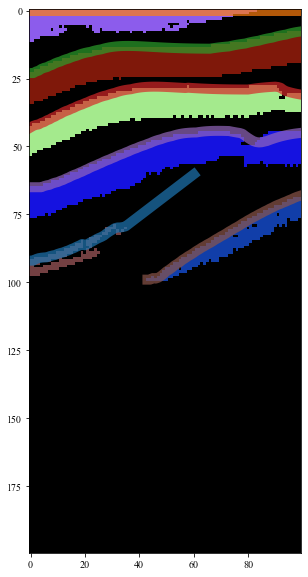

In [15]:
plt.figure(figsize=(20, 10))
plt.imshow(Labels, cmap= colormap, interpolation='none')
for i,traj in enumerate(trajs_pred):
    t, x = zip(*traj)
    plt.plot(t,x,label = f'pred_{i}', linewidth = 10,alpha = 0.7)
plt.show()

In [109]:
total_tp, total_fp, total_fn = 0, 0, 0
total_switch,total_discontinuity = 0,0
total_speed_errors, total_spatial_errors = [], []
total_occ_speed_errors, total_occ_spatial_errors = [], []
total_occ_acceleration_errors = []
total_acceleration_errors = []
total_recovered_trajs = []
speed_eva_window = 20
x_error_threshold = 4
time_space_diagram_list = os.listdir(dir_img)
db = Raster_DBSCAN(Td_map_szie=(lane_unit,time_span), window_size=[7,15],eps = 1,min_samples=1)
for frame_ind in tqdm(range(len(time_space_diagram_list))):
    time_space_diagram_name = time_space_diagram_list[frame_ind]
    trajectory_name = trajectory_list[frame_ind]
    time_space_diagram_raw = cv2.imread(os.path.join(dir_img,time_space_diagram_name), cv2.IMREAD_GRAYSCALE)
    traj_type_label,trajs_label = get_traj_labels(traj_dir,trajectory_name,time_space_diagram_raw)
    time_space_diagram_input = time_space_diagram_raw > 100
    time_space_diagram_input = time_space_diagram_input.astype(np.uint8)
    padding = np.zeros((lane_unit_num - time_space_diagram_input.shape[0], time_space_diagram_input.shape[1]))
    time_space_diagram_input = np.concatenate((time_space_diagram_input,padding), axis=0)
    Labels = db.fit_predict(time_space_diagram_input> 0, time_space_diagram_input > 0)
    trajs_pred = get_trajs_from_Kalman_out(Labels)
    break
    if len(trajs_pred) == 0:
        total_fn += len(trajs_label)
        continue
    # trajs_label = [traj for i, traj in enumerate(trajs_label) if traj_type_label[i] == 0]
    TrajIoUMatrix,TrajPortionMatrix = get_TrajIoU(trajs_label,trajs_pred,x_error_threshold = x_error_threshold)
    pred_index = TrajIoUMatrix.argmax(axis = 1)
    pred_IoU = TrajIoUMatrix.max(axis = 1)

    tp,fp,fn,id_switch,discontinuity = get_accuracy_metric(Iou_threshold, TrajIoUMatrix, TrajPortionMatrix, trajs_pred)
        
    speed_errors,spatial_errors,occ_speed_errors,occ_spatial_errors,acceleration_errors,occ_acceleration_errors = get_speed_spatial_error(trajs_label,trajs_pred,pred_index,pred_IoU,Iou_threshold,speed_eva_window,traj_type_label)
    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_switch += id_switch
    total_discontinuity += discontinuity
    total_speed_errors.append(speed_errors)
    total_spatial_errors.append(spatial_errors)
    total_occ_speed_errors.append(occ_speed_errors)
    total_occ_spatial_errors.append(occ_spatial_errors)
    total_occ_acceleration_errors.append(occ_acceleration_errors)
    total_acceleration_errors.append(acceleration_errors)

# print(total_tp,total_fp,total_fn,total_switch,total_discontinuity)
# total_occ_spatial_errors_Kalman = np.concatenate(total_occ_spatial_errors)
# total_occ_speed_errors_Kalman = np.concatenate(total_occ_speed_errors)
# total_speed_errors_Kalman = np.concatenate(total_speed_errors)
# total_spatial_errors_Kalman = np.concatenate(total_spatial_errors)
# total_acceleration_errors_Kalman = np.concatenate(total_acceleration_errors)
# total_occ_acceleration_errors_Kalman = np.concatenate(total_occ_acceleration_errors)

  0%|          | 0/325 [00:00<?, ?it/s]


In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(Labels, cmap= colormap, interpolation='none')
for i,traj in enumerate(trajectories_):
    t, x = zip(*traj)
    plt.plot(t,x,label = f'pred_{i}', linewidth = 10,alpha = 0.7)
plt.show()

In [106]:
center = False
max_prediction_count = 0
# Initialize storage for active tracks and completed trajectories
n_lane_cells, n_frames = Labels.shape
active_tracks = {}  # {track_id: {'filter': filter, 'last_update': t, 'pred_count': n, 'positions': [(t, pos)]}}
trajectories = {}   # {track_id: [(t, pos)]}
next_track_id = 0   # Counter for assigning unique track IDs
cur_t = 0
while True:
    Labels_t = Labels[:, cur_t]
    unique_id, xs, counts = np.unique(Labels_t, return_index=True, return_counts=True)
    # Skip background (-1) if present
    if unique_id[0] == -1:
        unique_id = unique_id[1:]
        xs = xs[1:]
        counts = counts[1:]
    if len(unique_id) > 0:
        if center:
            positions = xs + 0.5 * counts
        else:
            positions = xs
        current_detections = list(zip(unique_id, positions))
        for det_id, det_pos in current_detections: 
            # Create new track
            track_id = next_track_id
            next_track_id += 1
            
            active_tracks[track_id] = {
                'last_update': cur_t,
                'pred_count': 0,
                'positions': [(cur_t, det_pos)]
            }
        break
    cur_t += 1
    
for t in range(cur_t,n_frames):
    # Extract vehicle positions in current frame
    Labels_t = Labels[:, t]
    unique_id, xs, counts = np.unique(Labels_t, return_index=True, return_counts=True)
    # Skip background (-1) if present
    if unique_id[0] == -1:
        unique_id = unique_id[1:]
        xs = xs[1:]
        counts = counts[1:]
    # Calculate vehicle positions
    if center:
        positions = xs + 0.5 * counts
    else:
        positions = xs
    # Store current detections for association
    current_detections = list(zip(unique_id, positions))
    for track_id, track_data in list(active_tracks.items()):
        if len(track_data['positions']) >= input_frames:
            """
            LSTM prediction hetre
            """
            input_context = time_space_diagram_input_padded[:,t - input_frames + 1:t + 1]
            input_context = torch.from_numpy(input_context).unsqueeze(0).permute(0, 2, 1).float().to(device)
            input_positions = track_data['positions'][-input_frames:]
            input_positions = torch.from_numpy(np.array(input_positions)[:,1]).unsqueeze(0).to(device)
            with torch.no_grad():
                model.eval()
                pred_distributions = model(input_positions, input_context)
                predicted_pos = pred_distributions[0].cpu().numpy().flatten().argmax(axis=0)
            predicted_pos = float(predicted_pos)
            track_data['predicted_pos'] = predicted_pos
        else:
            # assume the predicted position is the last known position\
            predicted_pos = track_data['positions'][-1][1]
            track_data['predicted_pos'] = predicted_pos

     # Step 2: Associate detections with existing tracks using Hungarian algorithm
    if len(active_tracks) > 0 and len(current_detections) > 0:
        # Create cost matrix
        cost_matrix = np.zeros((len(active_tracks), len(current_detections)))
        for i, (track_id, track_data) in enumerate(active_tracks.items()):
            for j, (det_id, det_pos) in enumerate(current_detections):
                # Calculate distance between predicted position and detection
                distance = abs(track_data['predicted_pos'] - det_pos)
                
                # Apply a maximum threshold for association (e.g., 5 lane cells)
                if distance > 5.0:
                    cost_matrix[i, j] = 1000  # Large cost for impossible associations
                else:
                    cost_matrix[i, j] = distance
        # Apply Hungarian algorithm
        track_indices, detection_indices = linear_sum_assignment(cost_matrix)
        # Process associations
        associated_tracks = set()
        associated_detections = set()
        for i, j in zip(track_indices, detection_indices):
            # Only associate if the cost is below threshold
            if cost_matrix[i, j] < 1000:
                # Get track and detection
                track_id = list(active_tracks.keys())[i]
                det_id, det_pos = current_detections[j]
                
                # Update Kalman filter
                track_data = active_tracks[track_id]
                # Update track data
                track_data['last_update'] = t
                track_data['pred_count'] = 0  # Reset consecutive prediction count
                track_data['positions'].append((t, track_data['predicted_pos']))
                
                associated_tracks.add(track_id)
                associated_detections.add(det_id)
    else:
            associated_tracks = set()
            associated_detections = set()
    # Step 3: Create new tracks for unassociated detections
    for det_id, det_pos in current_detections:
        if det_id not in associated_detections:
            
            # Create new track
            track_id = next_track_id
            next_track_id += 1
            
            active_tracks[track_id] = {
                'last_update': t,
                'pred_count': 0,
                'positions': [(t, det_pos)]
            }
    # Step 4: Update unassociated tracks with prediction only
    for track_id, track_data in list(active_tracks.items()):
        if track_id not in associated_tracks:
            # Track was not associated with a detection
            track_data['pred_count'] += 1
            
            # If consecutive predictions exceed threshold, terminate track
            if track_data['pred_count'] > max_prediction_count:
                # Move to completed trajectories
                trajectories[track_id] = track_data['positions']
                del active_tracks[track_id]
            else:
                if len(track_data['positions']) >= input_frames:
                    # Continue track with prediction only
                    """
                    LSTM Prediction here
                    """
                    input_context = time_space_diagram_input_padded[:,t - input_frames + 1:t + 1]
                    input_context = torch.from_numpy(input_context).unsqueeze(0).permute(0, 2, 1).float().to(device)
                    input_positions = track_data['positions'][-input_frames:]
                    input_positions = torch.from_numpy(np.array(input_positions)[:,1]).unsqueeze(0).to(device)
                    # Extract predicted position (x[0])
                    with torch.no_grad():
                        model.eval()
                        pred_distributions = model(input_positions, input_context)
                        predicted_pos = pred_distributions[0].cpu().numpy().flatten().argmax(axis=0)
                    predicted_pos = float(predicted_pos)
                    track_data['positions'].append((t, predicted_pos))
                else:
                    # Assume the predicted position is the last known position
                    predicted_pos = track_data['positions'][-1][1]
                    track_data['positions'].append((t, predicted_pos))

# Add remaining active tracks to trajectories
for track_id, track_data in active_tracks.items():
    trajectories[track_id] = track_data['positions']
trajectories_ = []
for track_id, positions in trajectories.items():
    # Convert positions to numpy array
    positions = np.array(positions)
    # Append to list of trajectories
    trajectories_.append(positions)
    


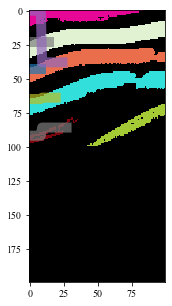

In [107]:
plt.figure(figsize=(6,5))
plt.imshow(Labels, cmap= colormap, interpolation='none')
for i,traj in enumerate(trajectories_):
    t, x = zip(*traj)
    plt.plot(t,x,label = f'pred_{i}', linewidth = 10,alpha = 0.7)
plt.show()